## Objective

This notebook performs Exploratory Data Analysis (EDA) to identify patterns and trends in the Olist e-commerce data.  
It focuses on sales performance, customer purchasing behavior, and operational efficiency using visual analysis to generate business insights.

### Load and overview

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
dim_customers = pd.read_csv('/content/drive/MyDrive/Olist_data/marts/dim_customers.csv')
dim_customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [14]:
dim_sellers = pd.read_csv('/content/drive/MyDrive/Olist_data/marts/dim_sellers.csv')
dim_sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [15]:
fact_sales = pd.read_csv('/content/drive/MyDrive/Olist_data/marts/fact_sales.csv')
fact_sales.head()

,order_id,customer_id,seller_id,product_id,payment_type,review_score,price,freight_value,revenue,delivery_time_days,order_purchase_timestamp,order_month,order_year
0,00e7ee1b050b8499577073aeb2a297a1,06b8999e2fba1a1fbc88172c00ba8bc7,7c67e1448b00f6e969d365cea6b010ab,a9516a079e37a9c9c36b9b78b10169e8,credit_card,4,124.99,21.88,146.87,8,2017-05-16 15:05:35,5,2017
1,29150127e6685892b6eab3eec79f59c7,18955e83d337fd6b2def6b18a428ac77,b8bc237ba3788b23da09c0f1f3a3288c,4aa6014eceb682077f9dc4bffebc05b0,credit_card,5,289.00,46.48,335.48,16,2018-01-12 20:48:24,1,2018
2,b2059ed67ce144a36e2aa97d2c9e9ad2,4e7b3e00288586ebd08712fdd0374a03,7c67e1448b00f6e969d365cea6b010ab,bd07b66896d6f1494f5b86251848ced7,credit_card,5,139.94,17.79,157.73,26,2018-05-19 16:07:45,5,2018
3,951670f92359f4fe4a63112aa7306eba,b2b6027bc5c5109e529d4dc6358b12c3,7c67e1448b00f6e969d365cea6b010ab,a5647c44af977b148e0a3a4751a09e2e,credit_card,5,149.94,23.36,173.30,14,2018-03-13 16:06:38,3,2018
4,6b7d50bd145f6fc7f33cebabd7e49d0f,4f2d8ab171c80ec8364f7c12e35b23ad,4a3ca9315b744ce9f8e9374361493884,9391a573abe00141c56e38d84d7d5b3b,credit_card,5,230.00,22.25,252.25,11,2018-07-29 09:51:30,7,2018


In [25]:
# Data Overview
print("Overview of dim_customers \n")
dim_customers.info()
print("\n")
dim_customers.describe(include='all')

Overview of dim_customers 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB




,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,274fa6071e5e17fe303b9748641082c8,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN


In [26]:
print("\Overview of dim_sellers ---\n")
dim_sellers.info()
print("\n")
dim_sellers.describe(include='all')

\Overview of dim_sellers ---

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB




<>:1: SyntaxWarning: invalid escape sequence '\O'
<>:1: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipykernel_677/3083018898.py:1: SyntaxWarning: invalid escape sequence '\O'
  print("\Overview of dim_sellers ---\n")


,seller_id,seller_zip_code_prefix,seller_city,seller_state
count,3095,3095.000000,3095,3095
unique,3095,NaN,611,23
top,9e25199f6ef7e7c347120ff175652c3b,NaN,sao paulo,SP
freq,1,NaN,694,1849
mean,NaN,32291.059451,NaN,NaN
std,NaN,32713.453830,NaN,NaN
min,NaN,1001.000000,NaN,NaN
25%,NaN,7093.500000,NaN,NaN
50%,NaN,14940.000000,NaN,NaN
75%,NaN,64552.500000,NaN,NaN


In [27]:
print("\n--- Overview of fact_sales ---\n")
fact_sales.info()
print("\n")
fact_sales.describe(include='all')


--- Overview of fact_sales ---

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113186 entries, 0 to 113185
Data columns (total 13 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   order_id                  113186 non-null  object 
 1   customer_id               113186 non-null  object 
 2   seller_id                 113186 non-null  object 
 3   product_id                113186 non-null  object 
 4   payment_type              113186 non-null  object 
 5   review_score              113186 non-null  int64  
 6   price                     113186 non-null  float64
 7   freight_value             113186 non-null  float64
 8   revenue                   113186 non-null  float64
 9   delivery_time_days        113186 non-null  int64  
 10  order_purchase_timestamp  113186 non-null  object 
 11  order_month               113186 non-null  int64  
 12  order_year                113186 non-null  int64  
dtypes: float64(

,order_id,customer_id,seller_id,product_id,payment_type,review_score,price,freight_value,revenue,delivery_time_days,order_purchase_timestamp,order_month,order_year
count,113186,113186,113186,113186,113186,113186.000000,113186.000000,113186.000000,113186.000000,113186.000000,113186,113186.000000,113186.000000
unique,94465,94465,2907,31474,4,NaN,NaN,NaN,NaN,NaN,93968,NaN,NaN
top,895ab968e7bb0d5659d16cd74cd1650c,270c23a11d024a44c896d1894b261a83,4a3ca9315b744ce9f8e9374361493884,aca2eb7d00ea1a7b8ebd4e68314663af,credit_card,NaN,NaN,NaN,NaN,NaN,2017-08-08 20:26:31,NaN,NaN
freq,63,63,2093,526,83527,NaN,NaN,NaN,NaN,NaN,63,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,4.082607,119.848353,20.002927,139.851281,11.976075,NaN,6.037257,2017.541984
std,NaN,NaN,NaN,NaN,NaN,1.345831,181.084433,15.712027,188.116473,9.361790,NaN,3.221866,0.504037
min,NaN,NaN,NaN,NaN,NaN,1.000000,0.850000,0.000000,6.080000,0.000000,NaN,1.000000,2016.000000
25%,NaN,NaN,NaN,NaN,NaN,4.000000,39.900000,13.080000,55.260000,6.000000,NaN,3.000000,2017.000000
50%,NaN,NaN,NaN,NaN,NaN,5.000000,74.900000,16.320000,91.780000,10.000000,NaN,6.000000,2018.000000
75%,NaN,NaN,NaN,NaN,NaN,5.000000,132.977500,21.190000,157.300000,15.000000,NaN,8.000000,2018.000000


## Sales Analysis

### Monthly Revenue

In [31]:
fact_sales['order_purchase_timestamp'] = pd.to_datetime(fact_sales['order_purchase_timestamp'])
print(fact_sales['order_purchase_timestamp'].dtype)

datetime64[ns]


In [33]:
monthly_revenue = fact_sales.groupby(['order_year', 'order_month'])['revenue'].sum().reset_index()
print("Monthly Revenue:")
print(monthly_revenue.head())

Monthly Revenue:
   order_year  order_month    revenue
0        2016           10   47398.24
1        2016           12      19.62
2        2017            1  133021.21
3        2017            2  272356.41
4        2017            3  427570.81


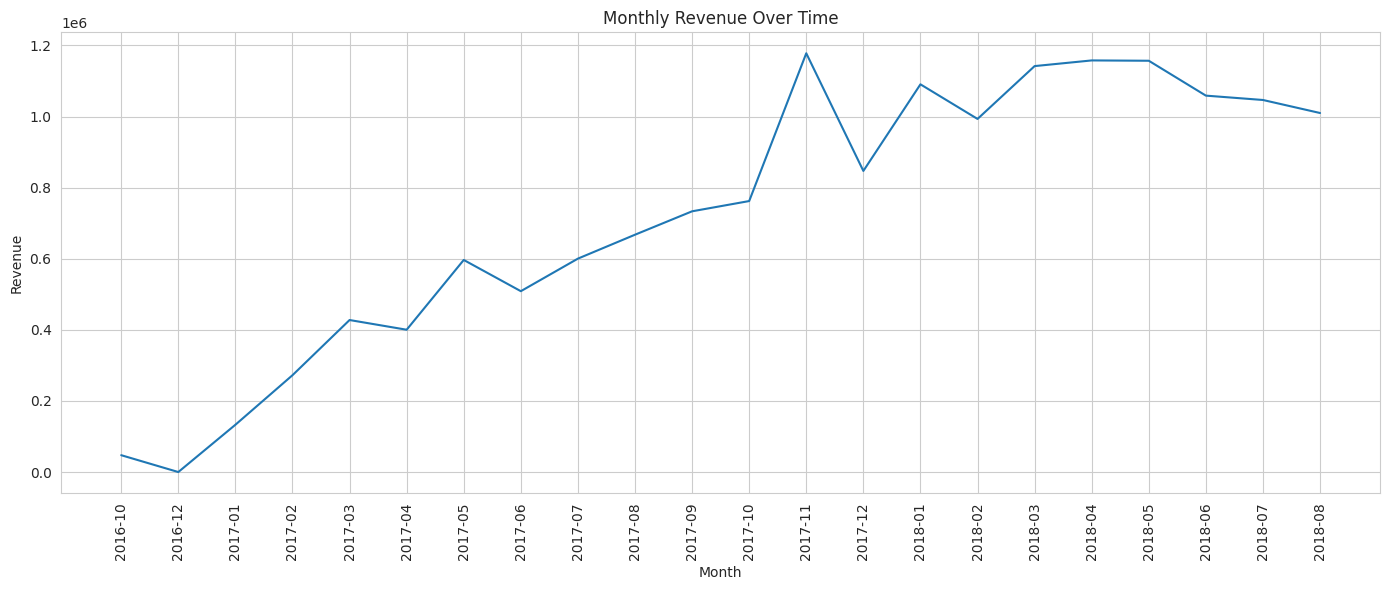

In [37]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_revenue, x=monthly_revenue.index, y='revenue')
plt.title('Monthly Revenue Over Time')
plt.xlabel('Month')
plt.ylabel('Revenue')
monthly_revenue['month_year'] = monthly_revenue['order_year'].astype(str) + '-' + monthly_revenue['order_month'].astype(str).str.zfill(2)
plt.xticks(ticks=monthly_revenue.index, labels=monthly_revenue['month_year'], rotation=90)
plt.grid(True)
plt.tight_layout()
plt.show()


### Category Performance

In [43]:
sales_with_products = pd.merge(fact_sales, products, on='product_id', how='left')
sales_with_products.head()

,order_id,customer_id,seller_id,product_id,payment_type,review_score,price,freight_value,revenue,delivery_time_days,...,order_month,order_year,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,00e7ee1b050b8499577073aeb2a297a1,06b8999e2fba1a1fbc88172c00ba8bc7,7c67e1448b00f6e969d365cea6b010ab,a9516a079e37a9c9c36b9b78b10169e8,credit_card,4,124.99,21.88,146.87,8,...,5,2017,moveis_escritorio,41.0,1141.0,1.0,8683.0,54.0,64.0,31.0
1,29150127e6685892b6eab3eec79f59c7,18955e83d337fd6b2def6b18a428ac77,b8bc237ba3788b23da09c0f1f3a3288c,4aa6014eceb682077f9dc4bffebc05b0,credit_card,5,289.00,46.48,335.48,16,...,1,2018,utilidades_domesticas,43.0,1002.0,3.0,10150.0,89.0,15.0,40.0
2,b2059ed67ce144a36e2aa97d2c9e9ad2,4e7b3e00288586ebd08712fdd0374a03,7c67e1448b00f6e969d365cea6b010ab,bd07b66896d6f1494f5b86251848ced7,credit_card,5,139.94,17.79,157.73,26,...,5,2018,moveis_escritorio,55.0,955.0,1.0,8267.0,52.0,52.0,17.0
3,951670f92359f4fe4a63112aa7306eba,b2b6027bc5c5109e529d4dc6358b12c3,7c67e1448b00f6e969d365cea6b010ab,a5647c44af977b148e0a3a4751a09e2e,credit_card,5,149.94,23.36,173.30,14,...,3,2018,moveis_escritorio,48.0,1066.0,1.0,12160.0,56.0,51.0,28.0
4,6b7d50bd145f6fc7f33cebabd7e49d0f,4f2d8ab171c80ec8364f7c12e35b23ad,4a3ca9315b744ce9f8e9374361493884,9391a573abe00141c56e38d84d7d5b3b,credit_card,5,230.00,22.25,252.25,11,...,7,2018,casa_conforto,61.0,407.0,1.0,5200.0,45.0,15.0,35.0


In [44]:
sales_category_data = pd.merge(sales_with_products, name_translations, on='product_category_name', how='left')
sales_category_data.head()

,order_id,customer_id,seller_id,product_id,payment_type,review_score,price,freight_value,revenue,delivery_time_days,...,order_year,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,00e7ee1b050b8499577073aeb2a297a1,06b8999e2fba1a1fbc88172c00ba8bc7,7c67e1448b00f6e969d365cea6b010ab,a9516a079e37a9c9c36b9b78b10169e8,credit_card,4,124.99,21.88,146.87,8,...,2017,moveis_escritorio,41.0,1141.0,1.0,8683.0,54.0,64.0,31.0,office_furniture
1,29150127e6685892b6eab3eec79f59c7,18955e83d337fd6b2def6b18a428ac77,b8bc237ba3788b23da09c0f1f3a3288c,4aa6014eceb682077f9dc4bffebc05b0,credit_card,5,289.00,46.48,335.48,16,...,2018,utilidades_domesticas,43.0,1002.0,3.0,10150.0,89.0,15.0,40.0,housewares
2,b2059ed67ce144a36e2aa97d2c9e9ad2,4e7b3e00288586ebd08712fdd0374a03,7c67e1448b00f6e969d365cea6b010ab,bd07b66896d6f1494f5b86251848ced7,credit_card,5,139.94,17.79,157.73,26,...,2018,moveis_escritorio,55.0,955.0,1.0,8267.0,52.0,52.0,17.0,office_furniture
3,951670f92359f4fe4a63112aa7306eba,b2b6027bc5c5109e529d4dc6358b12c3,7c67e1448b00f6e969d365cea6b010ab,a5647c44af977b148e0a3a4751a09e2e,credit_card,5,149.94,23.36,173.30,14,...,2018,moveis_escritorio,48.0,1066.0,1.0,12160.0,56.0,51.0,28.0,office_furniture
4,6b7d50bd145f6fc7f33cebabd7e49d0f,4f2d8ab171c80ec8364f7c12e35b23ad,4a3ca9315b744ce9f8e9374361493884,9391a573abe00141c56e38d84d7d5b3b,credit_card,5,230.00,22.25,252.25,11,...,2018,casa_conforto,61.0,407.0,1.0,5200.0,45.0,15.0,35.0,home_confort


In [46]:
category_performance = sales_category_data.groupby('product_category_name_english').agg(total_revenue=('revenue', 'sum'),number_of_sales=('order_id', 'count'),average_price=('price', 'mean')).reset_index()
print("Category Performance Metrics:\n")
category_performance.head()

Category Performance Metrics:



,product_category_name_english,total_revenue,number_of_sales,average_price
0,agro_industry_and_commerce,88638.00,246,332.835691
1,air_conditioning,60080.63,289,185.349758
2,art,27949.16,205,117.130390
3,arts_and_craftmanship,2184.14,24,75.583750
4,audio,57995.68,375,138.940480


In [54]:
top_10_revenue_categories = category_performance.sort_values(by='total_revenue', ascending=False).head(10)
print("Top 10 Product Categories by Total Revenue:\n")
top_10_revenue_categories

Top 10 Product Categories by Total Revenue:



,product_category_name_english,total_revenue,number_of_sales,average_price
43,health_beauty,1451396.82,9747,129.987954
70,watches_gifts,1308621.25,6030,200.224776
7,bed_bath_table,1296792.85,11684,92.595886
65,sports_leisure,1158691.20,8733,113.309708
15,computers_accessories,1072744.21,7926,116.386928
39,furniture_decor,923105.50,8554,87.254681
49,housewares,796570.75,7154,90.331698
20,cool_stuff,712740.73,3885,161.721640
5,auto,687739.19,4259,139.675332
42,garden_tools,591432.09,4451,110.158791


/tmp/ipykernel_677/232526815.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='product_category_name_english', y='total_revenue', data=top_10_revenue_categories, palette='viridis')


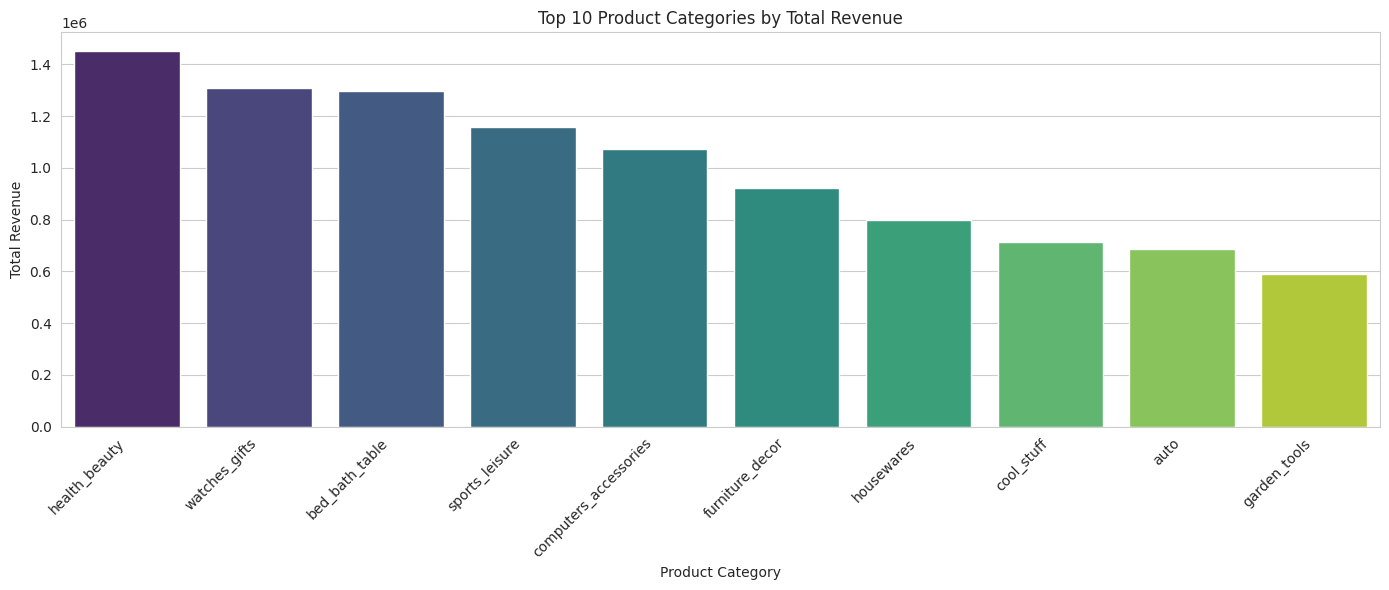

In [53]:
plt.figure(figsize=(14, 6))
sns.barplot(x='product_category_name_english', y='total_revenue', data=top_10_revenue_categories, palette='viridis')
plt.title('Top 10 Product Categories by Total Revenue')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [55]:
top_10_revenue_categories = category_performance.sort_values(by='total_revenue', ascending=False).head(10)
print("Top 10 Product Categories by Total Revenue:")
top_10_revenue_categories


Top 10 Product Categories by Total Revenue:


,product_category_name_english,total_revenue,number_of_sales,average_price
43,health_beauty,1451396.82,9747,129.987954
70,watches_gifts,1308621.25,6030,200.224776
7,bed_bath_table,1296792.85,11684,92.595886
65,sports_leisure,1158691.20,8733,113.309708
15,computers_accessories,1072744.21,7926,116.386928
39,furniture_decor,923105.50,8554,87.254681
49,housewares,796570.75,7154,90.331698
20,cool_stuff,712740.73,3885,161.721640
5,auto,687739.19,4259,139.675332
42,garden_tools,591432.09,4451,110.158791


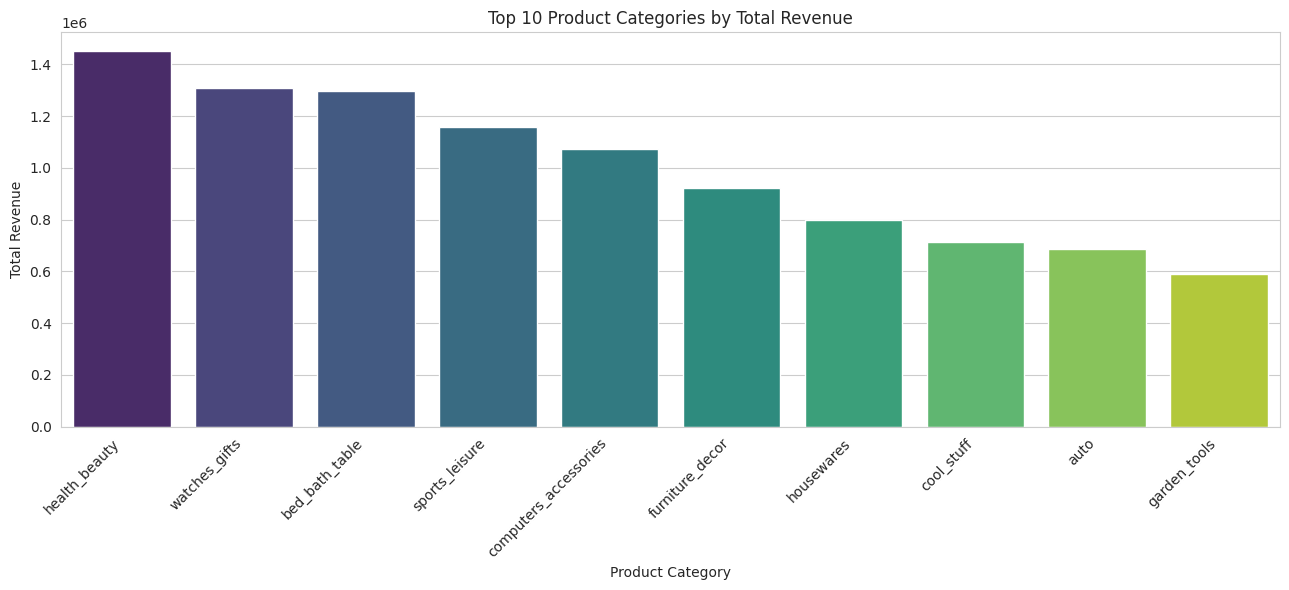

In [56]:
plt.figure(figsize=(13, 6))
sns.barplot(x='product_category_name_english', y='total_revenue', data=top_10_revenue_categories, palette='viridis', hue='product_category_name_english', legend=False)
plt.title('Top 10 Product Categories by Total Revenue')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Top Sellers

In [60]:
seller_performance = fact_sales.groupby('seller_id')['revenue'].sum().reset_index()
print("Seller Performance by Total Revenue:")
seller_performance.head()

Seller Performance by Total Revenue:


,seller_id,revenue
0,0015a82c2db000af6aaaf3ae2ecb0532,2748.06
1,001cca7ae9ae17fb1caed9dfb1094831,32977.86
2,002100f778ceb8431b7a1020ff7ab48f,2108.41
3,004c9cd9d87a3c30c522c48c4fc07416,21901.40
4,00720abe85ba0859807595bbf045a33b,1323.48


In [61]:
top_n_sellers = seller_performance.sort_values(by='revenue', ascending=False).head(10).reset_index(drop=True)
print("Top 10 Sellers by Total Revenue:")
top_n_sellers

Top 10 Sellers by Total Revenue:


,seller_id,revenue
0,4869f7a5dfa277a7dca6462dcf3b52b2,254453.79
1,53243585a1d6dc2643021fd1853d8905,251669.69
2,7c67e1448b00f6e969d365cea6b010ab,250650.70
3,4a3ca9315b744ce9f8e9374361493884,246505.51
4,fa1c13f2614d7b5c4749cbc52fecda94,209863.60
5,da8622b14eb17ae2831f4ac5b9dab84a,196730.46
6,7e93a43ef30c4f03f38b393420bc753a,178428.48
7,1025f0e2d44d7041d6cf58b6550e0bfa,176455.19
8,7a67c85e85bb2ce8582c35f2203ad736,169020.12
9,955fee9216a65b617aa5c0531780ce60,157877.50


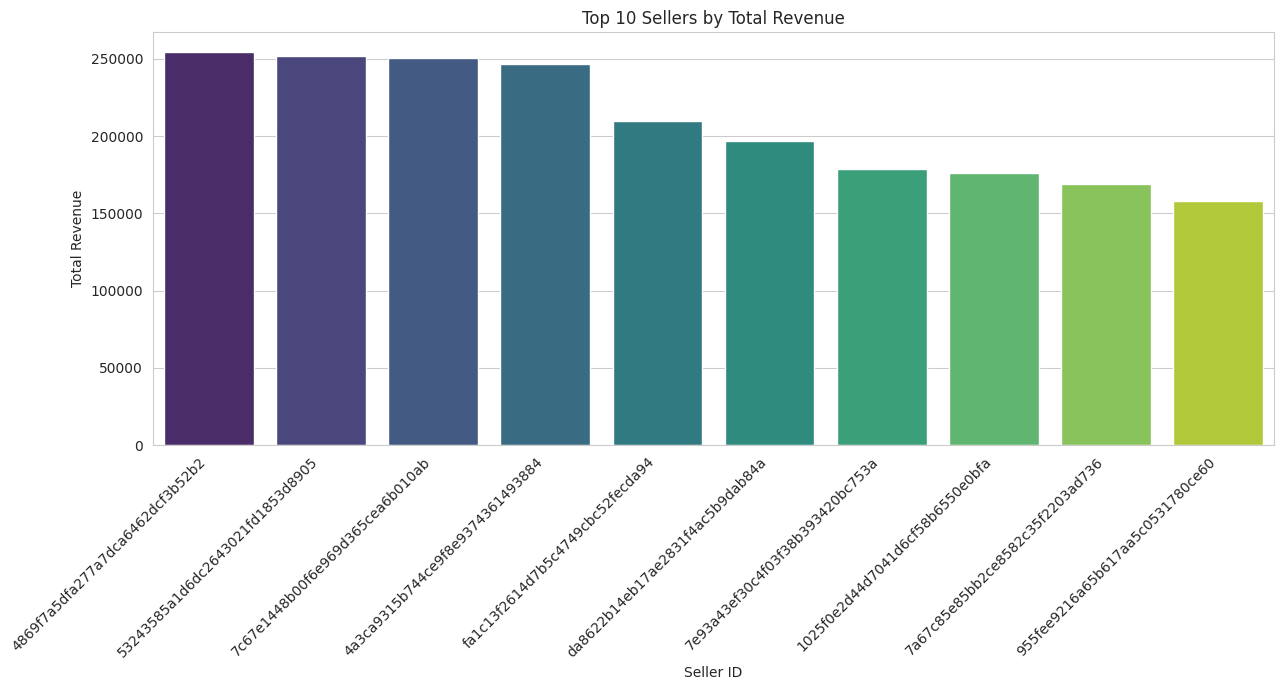

In [62]:
plt.figure(figsize=(13, 7))
sns.barplot(x='seller_id', y='revenue', data=top_n_sellers, palette='viridis', hue='seller_id', legend=False)
plt.title('Top 10 Sellers by Total Revenue')
plt.xlabel('Seller ID')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Customer Behavior

### Repeat Customers

In [63]:
sales_customers_merged = pd.merge(fact_sales, dim_customers, on='customer_id', how='left')
sales_customers_merged.head()

,order_id,customer_id,seller_id,product_id,payment_type,review_score,price,freight_value,revenue,delivery_time_days,order_purchase_timestamp,order_month,order_year,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,00e7ee1b050b8499577073aeb2a297a1,06b8999e2fba1a1fbc88172c00ba8bc7,7c67e1448b00f6e969d365cea6b010ab,a9516a079e37a9c9c36b9b78b10169e8,credit_card,4,124.99,21.88,146.87,8,2017-05-16 15:05:35,5,2017,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,29150127e6685892b6eab3eec79f59c7,18955e83d337fd6b2def6b18a428ac77,b8bc237ba3788b23da09c0f1f3a3288c,4aa6014eceb682077f9dc4bffebc05b0,credit_card,5,289.00,46.48,335.48,16,2018-01-12 20:48:24,1,2018,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,b2059ed67ce144a36e2aa97d2c9e9ad2,4e7b3e00288586ebd08712fdd0374a03,7c67e1448b00f6e969d365cea6b010ab,bd07b66896d6f1494f5b86251848ced7,credit_card,5,139.94,17.79,157.73,26,2018-05-19 16:07:45,5,2018,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,951670f92359f4fe4a63112aa7306eba,b2b6027bc5c5109e529d4dc6358b12c3,7c67e1448b00f6e969d365cea6b010ab,a5647c44af977b148e0a3a4751a09e2e,credit_card,5,149.94,23.36,173.30,14,2018-03-13 16:06:38,3,2018,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,6b7d50bd145f6fc7f33cebabd7e49d0f,4f2d8ab171c80ec8364f7c12e35b23ad,4a3ca9315b744ce9f8e9374361493884,9391a573abe00141c56e38d84d7d5b3b,credit_card,5,230.00,22.25,252.25,11,2018-07-29 09:51:30,7,2018,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [64]:
customer_orders = sales_customers_merged.groupby('customer_unique_id')['order_id'].count().reset_index(name='order_count')
repeat_customers = customer_orders[customer_orders['order_count'] > 1]
print("Customers with more than one order (Repeat Customers):")
repeat_customers.head()

Customers with more than one order (Repeat Customers):


,customer_unique_id,order_count
7,00053a61a98854899e70ed204dd4bafe,2
15,000bfa1d2f1a41876493be685390d6d3,2
18,000de6019bb59f34c099a907c151d855,2
19,000e309254ab1fc5ba99dd469d36bdb4,2
22,000fbf0473c10fc1ab6f8d2d286ce20c,4


In [65]:
total_repeat_customers = repeat_customers['customer_unique_id'].nunique()
repeat_customer_sales = sales_customers_merged[sales_customers_merged['customer_unique_id'].isin(repeat_customers['customer_unique_id'])]
total_revenue_from_repeat_customers = repeat_customer_sales['revenue'].sum()
print(f"Total number of repeat customers: {total_repeat_customers}")
print(f"Total revenue from repeat customers: {total_revenue_from_repeat_customers:.2f}")

Total number of repeat customers: 13734
Total revenue from repeat customers: 4100322.83


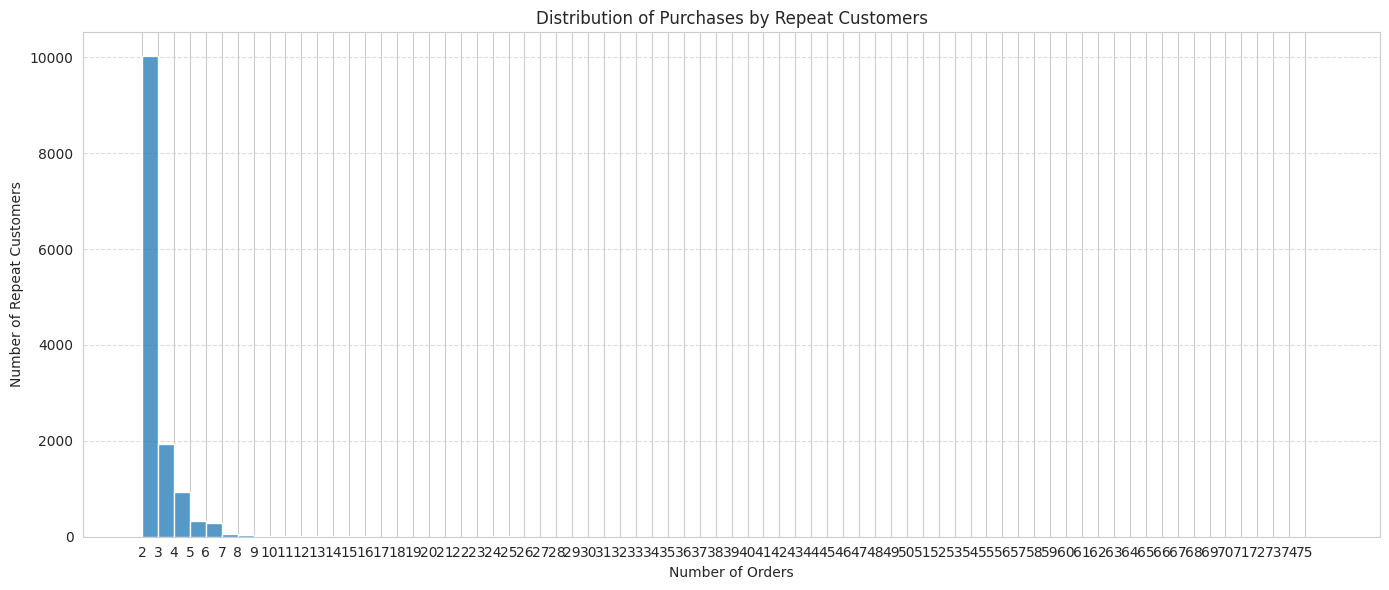

In [67]:
plt.figure(figsize=(14, 6))
sns.histplot(repeat_customers['order_count'], bins=range(2, repeat_customers['order_count'].max() + 2), kde=False)
plt.title('Distribution of Purchases by Repeat Customers')
plt.xlabel('Number of Orders')
plt.ylabel('Number of Repeat Customers')
plt.xticks(range(2, repeat_customers['order_count'].max() + 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Revenue Distribution

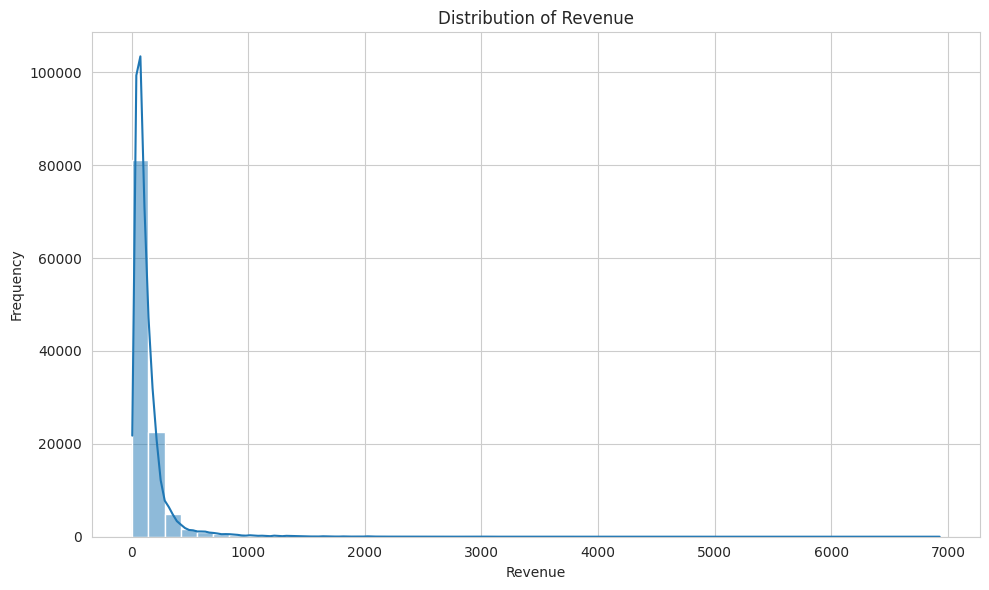

In [70]:
plt.figure(figsize=(10, 6))
sns.histplot(fact_sales['revenue'], bins=50, kde=True)
plt.title('Distribution of Revenue')
plt.xlabel('Revenue')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## Operations Analysis

### Delivery Time Distribution

In [74]:
print(f"Mean Delivery Time: {fact_sales['delivery_time_days'].mean():.2f} days")
print(f"Median Delivery Time: {fact_sales['delivery_time_days'].median():.2f} days")
print(f"Minimum Delivery Time: {fact_sales['delivery_time_days'].min()} days")
print(f"Maximum Delivery Time: {fact_sales['delivery_time_days'].max()} days")
print(f"Standard Deviation of Delivery Time: {fact_sales['delivery_time_days'].std():.2f} days")

Mean Delivery Time: 11.98 days
Median Delivery Time: 10.00 days
Minimum Delivery Time: 0 days
Maximum Delivery Time: 208 days
Standard Deviation of Delivery Time: 9.36 days


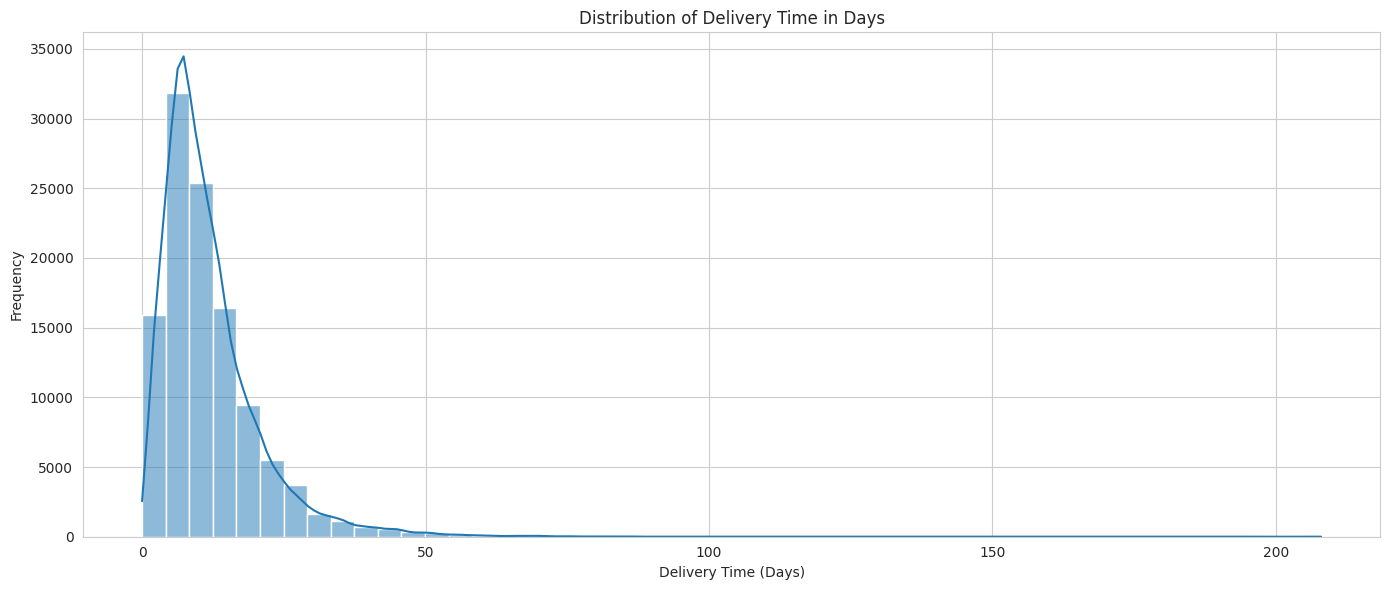

In [73]:
plt.figure(figsize=(14, 6))
sns.histplot(fact_sales['delivery_time_days'], bins=50, kde=True)
plt.title('Distribution of Delivery Time in Days')
plt.xlabel('Delivery Time (Days)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Delay vs Review Score

In [82]:
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'], errors='coerce')
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'], errors='coerce')
orders['delivery_delay'] = orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']
orders['delivery_delay_days'] = orders['delivery_delay'].dt.days
orders[['order_id', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'delivery_delay', 'delivery_delay_days']].head()

,order_id,order_delivered_customer_date,order_estimated_delivery_date,delivery_delay,delivery_delay_days
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-10 21:25:13,2017-10-18,-8 days +21:25:13,-8
1,53cdb2fc8bc7dce0b6741e2150273451,2018-08-07 15:27:45,2018-08-13,-6 days +15:27:45,-6
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-17 18:06:29,2018-09-04,-18 days +18:06:29,-18
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-12-02 00:28:42,2017-12-15,-13 days +00:28:42,-13
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-16 18:17:02,2018-02-26,-10 days +18:17:02,-10


In [84]:
def categorize_delivery_delay(days):
    if days < 0:
        return 'Early Delivery'
    elif days == 0:
        return 'On-time Delivery'
    elif 0 < days <= 5:
        return 'Slightly Delayed'
    elif 5 < days <= 15:
        return 'Moderately Delayed'
    else:
        return 'Highly Delayed'
orders['delivery_category'] = orders['delivery_delay_days'].apply(categorize_delivery_delay)
print("Delivery Category Distribution:")
orders['delivery_category'].value_counts()

Delivery Category Distribution:


,count
delivery_category,
Early Delivery,88630
Slightly Delayed,2770
Moderately Delayed,2538
On-time Delivery,1292
Highly Delayed,1225


In [78]:
sales_with_delivery_details = pd.merge(fact_sales, orders[['order_id', 'delivery_category']], on='order_id', how='left')
sales_with_delivery_details.head()

,order_id,customer_id,seller_id,product_id,payment_type,review_score,price,freight_value,revenue,delivery_time_days,order_purchase_timestamp,order_month,order_year,delivery_category
0,00e7ee1b050b8499577073aeb2a297a1,06b8999e2fba1a1fbc88172c00ba8bc7,7c67e1448b00f6e969d365cea6b010ab,a9516a079e37a9c9c36b9b78b10169e8,credit_card,4,124.99,21.88,146.87,8,2017-05-16 15:05:35,5,2017,Early Delivery
1,29150127e6685892b6eab3eec79f59c7,18955e83d337fd6b2def6b18a428ac77,b8bc237ba3788b23da09c0f1f3a3288c,4aa6014eceb682077f9dc4bffebc05b0,credit_card,5,289.00,46.48,335.48,16,2018-01-12 20:48:24,1,2018,Early Delivery
2,b2059ed67ce144a36e2aa97d2c9e9ad2,4e7b3e00288586ebd08712fdd0374a03,7c67e1448b00f6e969d365cea6b010ab,bd07b66896d6f1494f5b86251848ced7,credit_card,5,139.94,17.79,157.73,26,2018-05-19 16:07:45,5,2018,Slightly Delayed
3,951670f92359f4fe4a63112aa7306eba,b2b6027bc5c5109e529d4dc6358b12c3,7c67e1448b00f6e969d365cea6b010ab,a5647c44af977b148e0a3a4751a09e2e,credit_card,5,149.94,23.36,173.30,14,2018-03-13 16:06:38,3,2018,Early Delivery
4,6b7d50bd145f6fc7f33cebabd7e49d0f,4f2d8ab171c80ec8364f7c12e35b23ad,4a3ca9315b744ce9f8e9374361493884,9391a573abe00141c56e38d84d7d5b3b,credit_card,5,230.00,22.25,252.25,11,2018-07-29 09:51:30,7,2018,Early Delivery


In [85]:
avg_review_score_by_delivery = sales_with_delivery_details.groupby('delivery_category')['review_score'].mean().reset_index()
print("Average Review Score by Delivery Category:")
avg_review_score_by_delivery

Average Review Score by Delivery Category:


,delivery_category,review_score
0,Early Delivery,4.210514
1,Highly Delayed,1.727881
2,Moderately Delayed,1.739613
3,On-time Delivery,3.999319
4,Slightly Delayed,2.946268


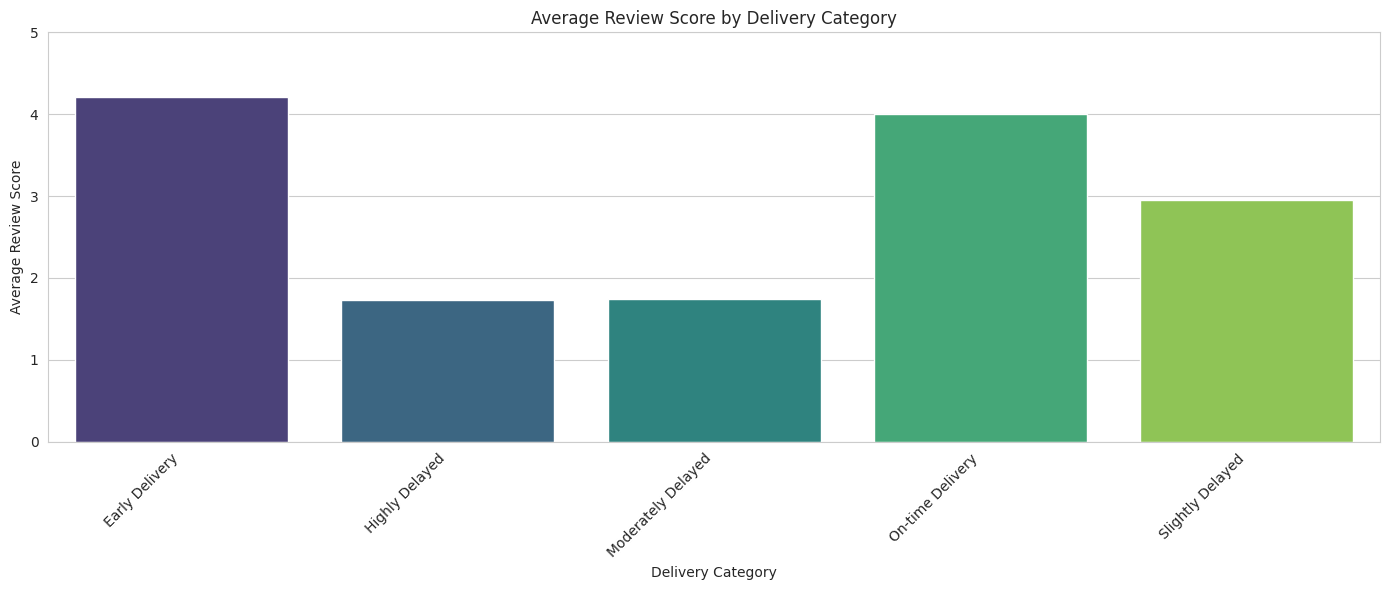

In [88]:
plt.figure(figsize=(14, 6))
sns.barplot(x='delivery_category', y='review_score', data=avg_review_score_by_delivery, palette='viridis', hue='delivery_category', legend=False)
plt.title('Average Review Score by Delivery Category')
plt.xlabel('Delivery Category')
plt.ylabel('Average Review Score')
plt.ylim(0, 5)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Key Takeaways

### Sales Performance
- Monthly revenue shows a clear growth trend across 2017–2018, indicating rapid platform expansion.
- The top revenue-generating categories are **Health & Beauty**, **Watches & Gifts**, and **Bed, Bath & Table**.
- Seller performance is highly concentrated, with a small number of sellers contributing a large share of total revenue.

### Customer Behavior
- A significant number of customers make repeat purchases, contributing substantially to total revenue.
- Most repeat customers place only **2–3 orders**, suggesting potential for retention strategies and loyalty programs.

### Operational Efficiency
- The average delivery time is approximately **12 days**, though delivery durations vary widely.
- Delivery speed strongly impacts customer satisfaction: **early or on-time deliveries receive high review scores**, while **delayed deliveries lead to significantly lower ratings**.